In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


In [2]:
data_path = "data/Mall_Customers.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}")

data = pd.read_csv(data_path)
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df = data.drop("CustomerID", axis=1)

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

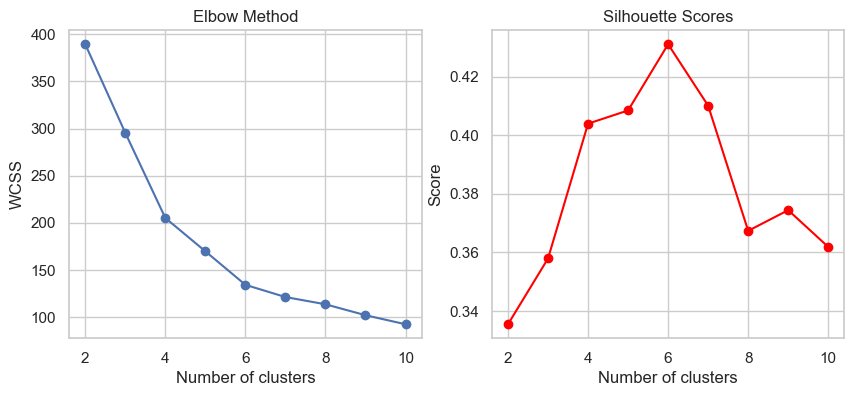

Optimal number of clusters: 6


In [4]:
wcss = []
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, cluster_labels))

# Plot WCSS (Elbow)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(range(2,11), sil_scores, marker='o', color='red')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.show()

# Choose optimal k (usually max silhouette or elbow point)
optimal_k = sil_scores.index(max(sil_scores)) + 2
print(f"Optimal number of clusters: {optimal_k}")


In [5]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,5
3,1,23,16,77,2
4,1,31,17,40,5


In [6]:

# Cluster counts
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Number of customers per cluster:\n", cluster_counts)

# Cluster mean features
cluster_profile = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(2)
print("\nAverage features per cluster:\n", cluster_profile)

# Gender distribution per cluster
gender_dist = df.groupby('Cluster')['Gender'].value_counts().unstack().fillna(0)
gender_dist.columns = ['Male','Female']
print("\nGender distribution per cluster:\n", gender_dist)


Number of customers per cluster:
 Cluster
0    45
1    39
2    25
3    40
4    30
5    21
Name: count, dtype: int64

Average features per cluster:
            Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        56.33               54.27                   49.07
1        32.69               86.54                   82.13
2        25.56               26.48                   76.24
3        26.12               59.42                   44.45
4        44.00               90.13                   17.93
5        45.52               26.29                   19.38

Gender distribution per cluster:
          Male  Female
Cluster              
0          19      26
1          18      21
2          11      14
3          16      24
4          16      14
5           8      13


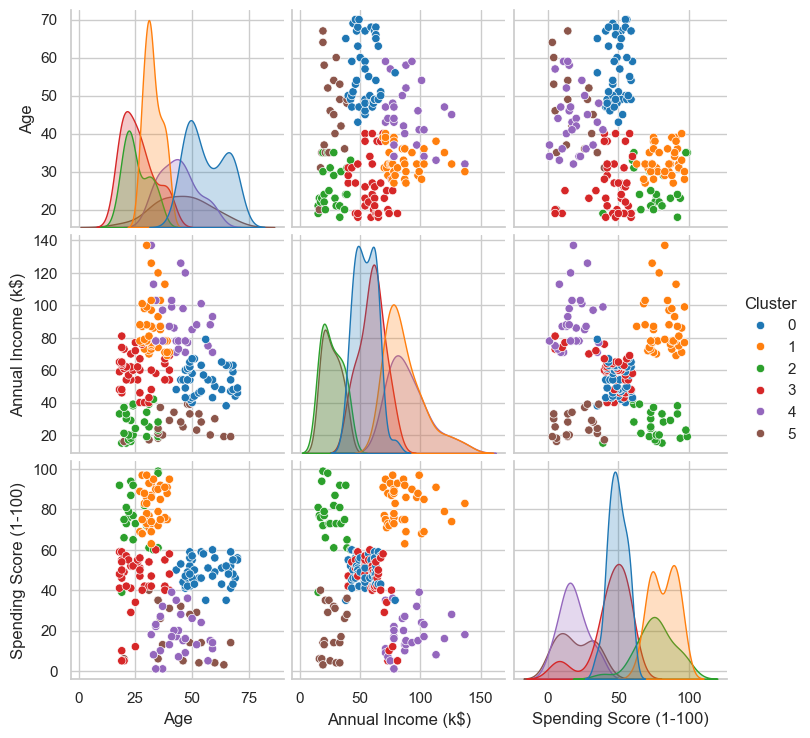

In [7]:
sns.pairplot(df, vars=['Age','Annual Income (k$)','Spending Score (1-100)'], hue='Cluster', palette='tab10')
plt.show()

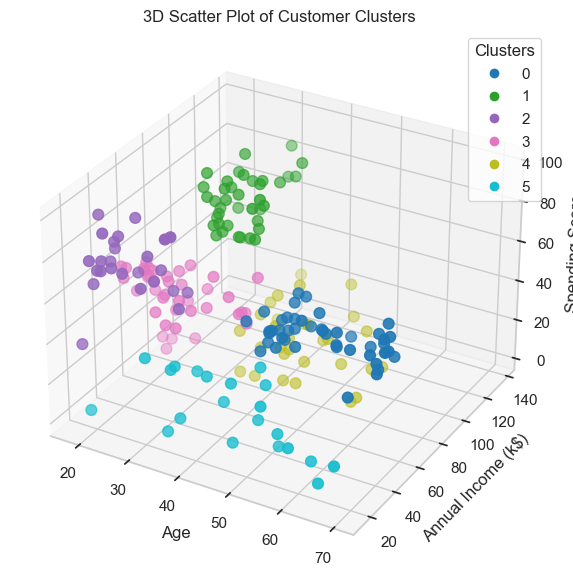

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Cluster'], cmap='tab10', s=60)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
plt.title("3D Scatter Plot of Customer Clusters")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [9]:
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score of clustering: {score:.3f}")

Silhouette Score of clustering: 0.431


In [10]:
output_path = "data/clustered_customers.csv"
df.to_csv(output_path, index=False)
print(f"Clustered data saved at {output_path}")


Clustered data saved at data/clustered_customers.csv
